In [22]:
##Wind Speed

#https://benny.istan.to/blog/20230401-visualising-the-wrf-output
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from windrose import WindroseAxes

#for the animation
import matplotlib.animation as animation


In [9]:
#load in data - with u and v components of wind
df16 = pd.read_csv('../../03ProcessedData/HourlyMeans_2016_052025.csv') 
df17 = pd.read_csv('../../03ProcessedData/HourlyMeans_2017_052025.csv') 
#df17s = pd.read_csv('../../03ProcessedData/HourlyMeans_2017_w16SST_052025.csv') 

#if you want distance to ocean
#d2o16 = pd.read_csv('../../03ProcessedData/Dist2Ocean_2016.csv') 
#d2o17 = pd.read_csv('../../03ProcessedData/Dist2Ocean_2017.csv') 
#d2o17s = pd.read_csv('../../03ProcessedData/HDist2Ocean_2017_w16SST.csv') 

In [5]:
df16

,GridCell,lat,long,hour,2mTemp,RelHumid,UWind_l1,VWind_l1,UWind_l2,VWind_l2,UWind_lm,VWind_lm,UWind_m,VWind_m,UWind_mh,VWind_mh,UWind_h,VWind_h,SWDown,LandUse
0,1.0,28.705856,-96.505585,0.0,292.420074,41.518112,-2.804418,0.360381,-3.433832,0.327582,-0.841724,-1.051096,21.066389,6.692110,51.417534,10.666225,8.954288,2.880076,186.647446,13.0
1,2.0,28.705856,-96.495407,0.0,292.211517,43.839798,-2.802368,0.460569,-3.388647,0.382439,-0.876739,-1.039902,21.064722,6.694211,51.411682,10.653605,8.959095,2.890794,186.008560,5.0
2,3.0,28.705856,-96.485237,0.0,292.092163,44.033169,-2.815126,0.535438,-3.341189,0.423103,-0.909539,-1.023534,21.063820,6.696887,51.406013,10.641478,8.966471,2.899807,185.783203,12.0
3,4.0,28.705856,-96.475060,0.0,292.251221,43.381466,-2.920779,0.564355,-3.281457,0.425001,-0.963284,-0.971951,21.061819,6.699613,51.400166,10.629976,8.975074,2.906380,185.531418,12.0
4,5.0,28.705856,-96.464890,0.0,292.247711,43.141148,-2.959013,0.580105,-3.263030,0.423313,-0.968358,-0.900286,21.057138,6.702624,51.395344,10.619239,8.988194,2.912116,185.199829,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007203,41963.0,30.685158,-94.216675,23.0,293.901642,35.546341,-0.899014,0.791888,-1.030506,0.986758,-0.204359,2.716769,21.131918,6.739296,52.962688,9.844318,9.424047,4.776003,389.124329,2.0
1007204,41964.0,30.685158,-94.206505,23.0,293.912354,35.449581,-0.796306,0.777698,-0.934109,0.978544,-0.344196,2.780243,21.132444,6.743253,52.961357,9.833837,9.449073,4.761013,388.865723,2.0
1007205,41965.0,30.685158,-94.196327,23.0,293.989594,35.194435,-0.738811,0.800982,-0.865795,0.997747,-0.497760,2.798499,21.135965,6.738969,52.957169,9.819538,9.478058,4.743011,388.589539,2.0
1007206,41966.0,30.685158,-94.186157,23.0,294.046539,34.869919,-0.725501,0.816174,-0.831131,1.024245,-0.693621,2.622718,21.143335,6.732457,52.949867,9.804008,9.514461,4.730604,388.313629,2.0


In [10]:
##Start calculating wind speed and direction - 2016
df16['WindSpeed_l1'] = ( df16['UWind_l1'] ** 2 + df16['VWind_l1'] ** 2) ** 0.5
df16['WindDirection_l1'] = 180 + (180 / np.pi) * np.arctan2(df16['VWind_l1'], df16['UWind_l1'])

df16['WindSpeed_l2'] = ( df16['UWind_l2'] ** 2 + df16['VWind_l2'] ** 2) ** 0.5
df16['WindDirection_l2'] = 180 + (180 / np.pi) * np.arctan2(df16['VWind_l2'], df16['UWind_l2'])

df16['WindSpeed_lm'] = ( df16['UWind_lm'] ** 2 + df16['VWind_lm'] ** 2) ** 0.5
df16['WindDirection_lm'] = 180 + (180 / np.pi) * np.arctan2(df16['VWind_lm'], df16['UWind_lm'])

df16['WindSpeed_m'] = ( df16['UWind_m'] ** 2 + df16['VWind_m'] ** 2) ** 0.5
df16['WindDirection_m'] = 180 + (180 / np.pi) * np.arctan2(df16['VWind_m'], df16['UWind_m'])

df16['WindSpeed_mh'] = ( df16['UWind_mh'] ** 2 + df16['VWind_mh'] ** 2) ** 0.5
df16['WindDirection_mh'] = 180 + (180 / np.pi) * np.arctan2(df16['VWind_mh'], df16['UWind_mh'])

df16['WindSpeed_h'] = ( df16['UWind_h'] ** 2 + df16['VWind_h'] ** 2) ** 0.5
df16['WindDirection_h'] = 180 + (180 / np.pi) * np.arctan2(df16['VWind_h'], df16['UWind_h'])

In [11]:
#calculate wind speed and direction - 2017
df17['WindSpeed_l1'] = ( df17['UWind_l1'] ** 2 + df17['VWind_l1'] ** 2) ** 0.5
df17['WindDirection_l1'] = 180 + (180 / np.pi) * np.arctan2(df17['VWind_l1'], df17['UWind_l1'])

df17['WindSpeed_l2'] = ( df17['UWind_l2'] ** 2 + df17['VWind_l2'] ** 2) ** 0.5
df17['WindDirection_l2'] = 180 + (180 / np.pi) * np.arctan2(df17['VWind_l2'], df17['UWind_l2'])

df17['WindSpeed_lm'] = ( df17['UWind_lm'] ** 2 + df17['VWind_lm'] ** 2) ** 0.5
df17['WindDirection_lm'] = 180 + (180 / np.pi) * np.arctan2(df17['VWind_lm'], df17['UWind_lm'])

df17['WindSpeed_m'] = ( df17['UWind_m'] ** 2 + df17['VWind_m'] ** 2) ** 0.5
df17['WindDirection_m'] = 180 + (180 / np.pi) * np.arctan2(df17['VWind_m'], df17['UWind_m'])

df17['WindSpeed_mh'] = ( df17['UWind_mh'] ** 2 + df17['VWind_mh'] ** 2) ** 0.5
df17['WindDirection_mh'] = 180 + (180 / np.pi) * np.arctan2(df17['VWind_mh'], df17['UWind_mh'])

df17['WindSpeed_h'] = ( df17['UWind_h'] ** 2 + df17['VWind_h'] ** 2) ** 0.5
df17['WindDirection_h'] = 180 + (180 / np.pi) * np.arctan2(df17['VWind_h'], df17['UWind_h'])

Now start working on the visuals

The code I am pulling from uses an xarray so might have to modify it a bit to use info in an array format instead..

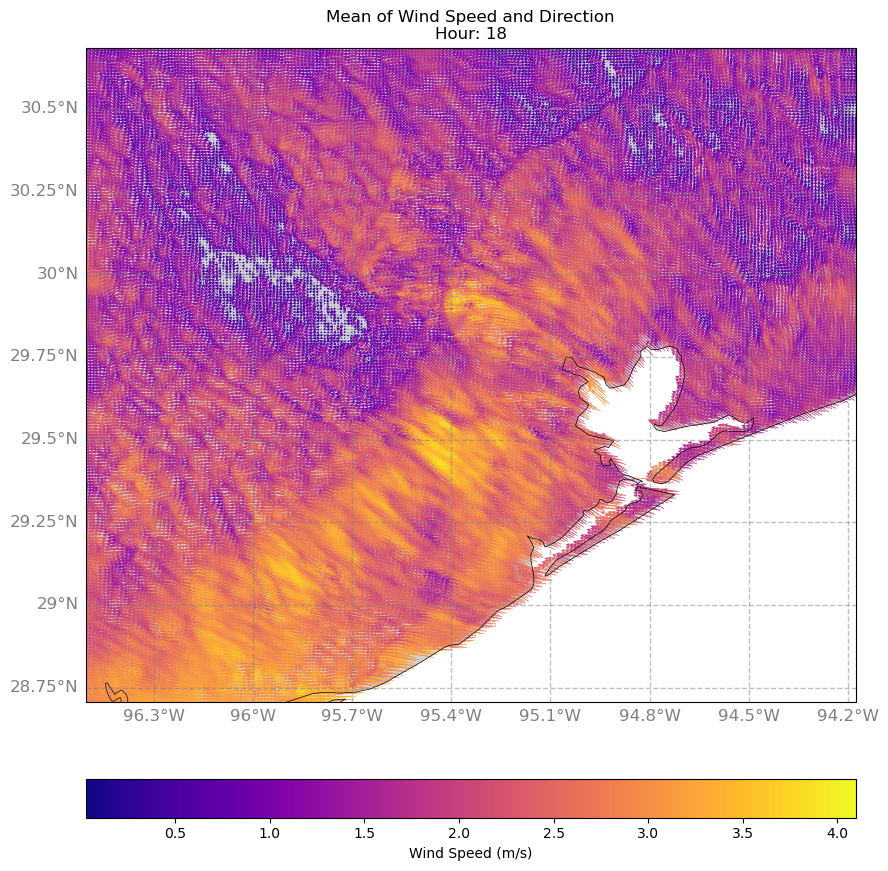

In [48]:
#########Start on the 2016 plot
# Create a map projection
proj = ccrs.PlateCarree()

# Create a figure and axis object
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection=proj))

# Set the plot extent
ax.set_extent([min(df16['long']), max(df16['long']), min(df16['lat']), max(df16['lat'])])

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# Add the latitude and longitude grid
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12, 'color': 'gray'}
gl.ylabel_style = {'size': 12, 'color': 'gray'}

##try to set this up for an animation
# Use hour 0 to initialize
df0 = df16[df16['hour'] == 0.0]

positions = np.column_stack((df0['long'], df0['lat']))
q = ax.quiver(df0['long'], df0['lat'],
              df0['UWind_l1'], df0['VWind_l1'], df0['WindSpeed_l1'],
              transform=ccrs.PlateCarree(), cmap='plasma', pivot='middle',
              width=0.001, scale=100, headwidth=5)

# Colorbar
cbar = fig.colorbar(q, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.ax.set_xlabel('Wind Speed (m/s)')


def update(frame):
    
    #for each frame, update the data stored on each axis
    h = float(frame)
    
    ##Pick an example time of day to look at
    df16_hr = df16[df16['hour'] == h]

    ## Set positions first
    positions = np.column_stack((df16_hr['long'], df16_hr['lat']))
    q.set_offsets(positions)
    
    q.set_UVC(df16_hr['UWind_l1'], df16_hr['VWind_l1'], df16_hr['WindSpeed_l1'])
    
    # q= ax.quiver(ds16_hr['long'], ds16_hr['lat'], df16_hr['UWind_l1'], df16_hr['VWind_l1'], df16_hr['WindSpeed_l1'],
    #      transform=ccrs.PlateCarree(), cmap='plasma', pivot='middle', width=0.001, scale=100, headwidth=5)

    hr = (24 + frame - 6) if frame < 6 else (frame - 6)

    # Add a title
    ax.set_title(f'Mean of Wind Speed and Direction\nHour: {hr}')
    
    return q,


#show the animation
ani = animation.FuncAnimation(fig=fig, func=update, frames=range(24), blit=False)

ani.save('WindSpeed_example.gif', writer='pillow', fps=3)
